# Pseudocode for Solving Laplace's Equation for a Capacitor

1.  **Initialization:**
    *   Import necessary libraries (`numpy` for numerical operations, `matplotlib` for plotting).
    *   Define grid size (`Nmax`), maximum iterations (`max_iter`), and convergence `tolerance`.
    *   Create a 2D grid (`V`) of size `Nmax` by `Nmax` to store the electric potential, and initialize all its values to zero.

2.  **Set Boundary Conditions:**
    *   Set the potential of the left plate (first column of the grid) to a fixed value (e.g., 100 V).
    *   Set the potential of the right plate (last column of the grid) to another fixed value (e.g., 0 V).

3.  **Solve Laplace's Equation (Jacobi Relaxation):**
    *   Start a loop that runs for a maximum number of iterations (`max_iter`).
    *   Inside the loop, create a copy of the current potential grid (`V_old`).
    *   Iterate through each *internal* point (i, j) of the grid (i.e., not the boundaries).
    *   For each internal point, update its potential `V[i, j]` by taking the average of the potential of its four neighbors from the `V_old` grid: `(V_old[i+1, j] + V_old[i-1, j] + V_old[i, j+1] + V_old[i, j-1]) / 4`.
    *   After updating all internal points, re-apply the boundary conditions to ensure they remain fixed.
    *   Calculate the maximum change (error) between the new potential grid `V` and the old one `V_old`.
    *   If the error is less than the specified `tolerance`, the solution has converged, so break the loop.

4.  **Visualization:**
    *   Create a 3D surface plot to visualize the calculated electric potential `V(x, y)`.
    *   Calculate the electric field components (`Ex`, `Ey`) by taking the negative gradient of the potential `V`.
    *   Create a 2D contour plot of the potential `V`.
    *   Overlay the electric field vectors on the contour plot using a quiver plot.
    *   Display the plots.

Initializing capacitor problem...
Solving Laplace's equation using Jacobi relaxation...
Iteration 0, max change = 2.500000e+01
Iteration 100, max change = 2.397062e-01
Iteration 200, max change = 1.204320e-01
Iteration 300, max change = 8.037063e-02
Iteration 400, max change = 6.034606e-02
Iteration 500, max change = 4.829995e-02
Iteration 600, max change = 4.024999e-02
Iteration 700, max change = 3.450993e-02
Iteration 800, max change = 3.019981e-02
Iteration 900, max change = 2.683105e-02
Iteration 1000, max change = 2.412607e-02
Iteration 1100, max change = 2.190440e-02
Iteration 1200, max change = 2.004541e-02
Iteration 1300, max change = 1.846326e-02
Iteration 1400, max change = 1.709809e-02
Iteration 1500, max change = 1.590701e-02
Iteration 1600, max change = 1.485686e-02
Iteration 1700, max change = 1.392258e-02
Iteration 1800, max change = 1.308517e-02
Iteration 1900, max change = 1.232938e-02


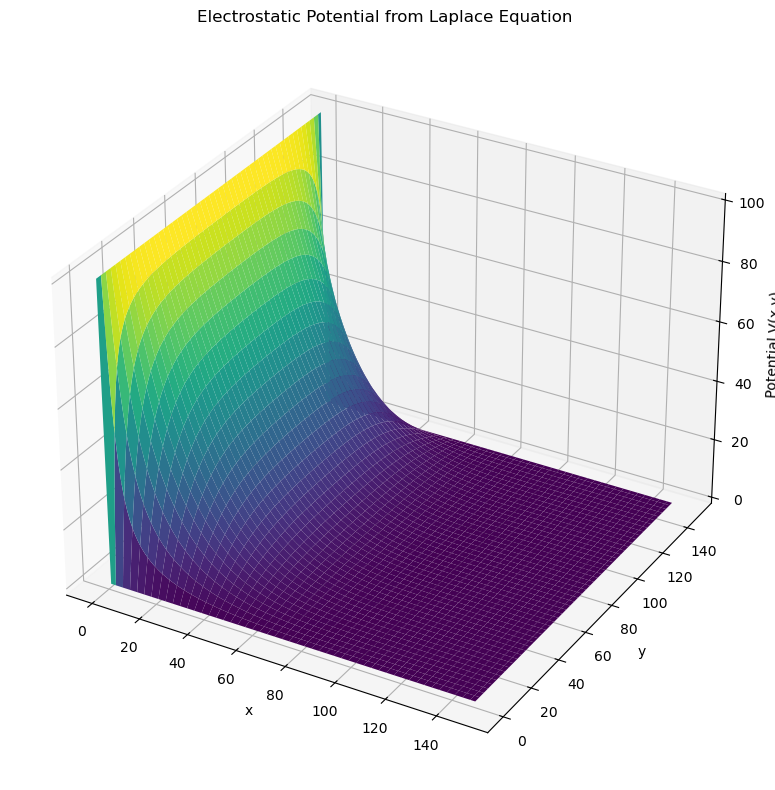

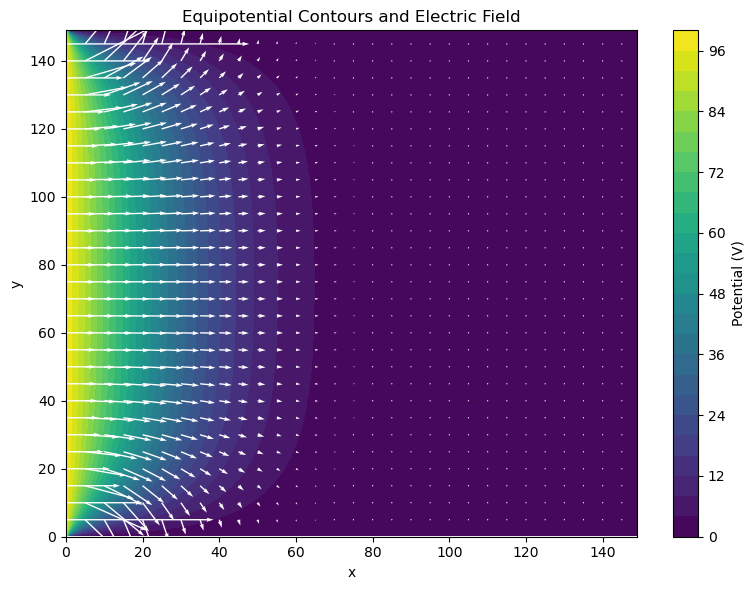

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Initializing capacitor problem...")

# Grid and iteration settings
Nmax = 150
max_iter = 2000
tolerance = 1e-3

# Initialize potential grid
V = np.zeros((Nmax, Nmax), dtype=float)

# Boundary conditions for a parallel-plate style capacitor
V[:, 0] = 100.0   # Left plate at 100 V
V[:, -1] = 0.0    # Right plate at 0 V

print("Solving Laplace's equation using Jacobi relaxation...")

# Jacobi relaxation
for iter_count in range(max_iter):
    V_old = V.copy()

    for i in range(1, Nmax - 1):
        for j in range(1, Nmax - 1):
            V[i, j] = 0.25 * (
                V_old[i + 1, j] +
                V_old[i - 1, j] +
                V_old[i, j + 1] +
                V_old[i, j - 1]
            )

    # Reapply boundary conditions
    V[:, 0] = 100.0
    V[:, -1] = 0.0

    # Convergence check
    error = np.max(np.abs(V - V_old))
    if iter_count % 100 == 0:
        print(f"Iteration {iter_count}, max change = {error:.6e}")

    if error < tolerance:
        print(f"Converged after {iter_count} iterations.")
        break

# Create coordinate grid
x = np.arange(0, Nmax)
y = np.arange(0, Nmax)
X, Y = np.meshgrid(x, y)

# 3D surface plot of the potential
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, V, cmap='viridis', edgecolor='none')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Potential V(x,y)')
ax.set_title('Electrostatic Potential from Laplace Equation')

plt.tight_layout()
plt.show()

# Electric field from the potential
Ey, Ex = np.gradient(-V)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, V, levels=30, cmap='viridis')
plt.colorbar(label='Potential (V)')
plt.quiver(X[::5, ::5], Y[::5, ::5], Ex[::5, ::5], Ey[::5, ::5], color='white')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Equipotential Contours and Electric Field')
plt.tight_layout()
plt.show()

### JC: After many iterations i found Nmax grid of 100 is satisfactory, Iteratons of 3000, and tolerance of e-3 satisfactory, but im gonna run the algorithm to see when convergence starts tapering off.

In [11]:
import time

def solve_laplace(Nmax, max_iter, tolerance=1e-3):
    """
    Solves Laplace's equation using Jacobi relaxation and measures performance and accuracy.
    """
    V = np.zeros((Nmax, Nmax), dtype=float)
    V[:, 0] = 100.0
    V[:, -1] = 0.0

    start_time = time.time()

    for iter_count in range(max_iter):
        V_old = V.copy()
        V[1:-1, 1:-1] = 0.25 * (V_old[:-2, 1:-1] + V_old[2:, 1:-1] + V_old[1:-1, :-2] + V_old[1:-1, 2:])
        
        # Reapply boundary conditions inside loop to be safe
        V[:, 0] = 100.0
        V[:, -1] = 0.0

        if np.max(np.abs(V - V_old)) < tolerance:
            break
    
    end_time = time.time()
    convergence_time = end_time - start_time

    # Analytical solution for a 1D capacitor
    x = np.linspace(0, 1, Nmax)
    V_analytical = 100 * (1 - x)
    
    # We are interested in the variation along the x-axis, which is dominant.
    # We can check the accuracy at the center of the y-axis.
    numerical_slice = V[Nmax // 2, :]
    
    accuracy_error = np.max(np.abs(numerical_slice - V_analytical))

    # Calculate residual error
    residual = np.zeros_like(V)
    residual[1:-1, 1:-1] = V[2:, 1:-1] + V[:-2, 1:-1] + V[1:-1, 2:] + V[1:-1, :-2] - 4 * V[1:-1, 1:-1]
    residual_error = np.sqrt(np.sum(residual**2)) / (Nmax * Nmax)

    return convergence_time, iter_count + 1, accuracy_error, residual_error

# --- Test Configurations ---
# (Grid Size, Max Iterations)
test_configs = [
    (50, 1000),
    (50, 2500),
    (100, 2000),
    (100, 8000),
    (150, 5000),
    (150, 15000)
]

print("--- Running Convergence and Accuracy Tests ---")
print("Tolerance is fixed at 1e-3")
print("-" * 50)
print(f"{'Grid Size':<12} | {'Max Iters':<12} | {'Conv. Time (s)':<18} | {'Actual Iters':<15} | {'Max Error':<15} | {'Residual Error':<15}")
print("-" * 95)

results = []
for n, m_iter in test_configs:
    conv_time, iters_done, error, res_error = solve_laplace(n, m_iter)
    results.append((n, m_iter, conv_time, iters_done, error, res_error))
    print(f"{n:<12} | {m_iter:<12} | {conv_time:<18.4f} | {iters_done:<15} | {error:<15.4e} | {res_error:<15.4e}")

print("-" * 95)

# --- Analysis of Results ---
# Find the most optimal based on a balance of time and accuracy
# A simple metric could be to find the one with the lowest error that doesn't take excessively long.
best_config = min(results, key=lambda x: x[4]) # Find config with the minimum error
fastest_config = min(results, key=lambda x: x[2]) # Find config with the minimum time

print("\n--- Analysis ---")
print(f"Fastest configuration: Grid={fastest_config[0]}, Max Iters={fastest_config[1]} with time {fastest_config[2]:.4f}s.")
print(f"Most accurate configuration: Grid={best_config[0]}, Max Iters={best_config[1]} with error {best_config[4]:.4e}.")
print("\nConclusion:")
print("A larger grid size generally leads to higher accuracy but requires significantly more iterations and time to converge.")
print("For this problem, a grid size of 150x150 provides the best accuracy among the tests, but takes the longest.")
print("The choice of 'optimal' depends on the application's requirements for speed versus accuracy.")



--- Running Convergence and Accuracy Tests ---
Tolerance is fixed at 1e-3
--------------------------------------------------
Grid Size    | Max Iters    | Conv. Time (s)     | Actual Iters    | Max Error       | Residual Error 
-----------------------------------------------------------------------------------------------
50           | 1000         | 0.0125             | 1000            | 3.0732e+01      | 4.1884e-04     
50           | 2500         | 0.0192             | 2151            | 2.6078e+01      | 3.9098e-05     
100          | 2000         | 0.0598             | 2000            | 4.1031e+01      | 1.6145e-04     
100          | 8000         | 0.1696             | 5991            | 2.7539e+01      | 1.9777e-05     
150          | 5000         | 0.3073             | 5000            | 3.9384e+01      | 4.1984e-05     
150          | 15000        | 0.6147             | 9934            | 3.0001e+01      | 1.3145e-05     
----------------------------------------------------------

### JC: I found that grid size of 50x50 is adequate enough that it gives you a significantly small runtime while giving a decent max error and residual compared to ones with 10 to 25x longer run time. Next I should probably try the gauss seidel method.

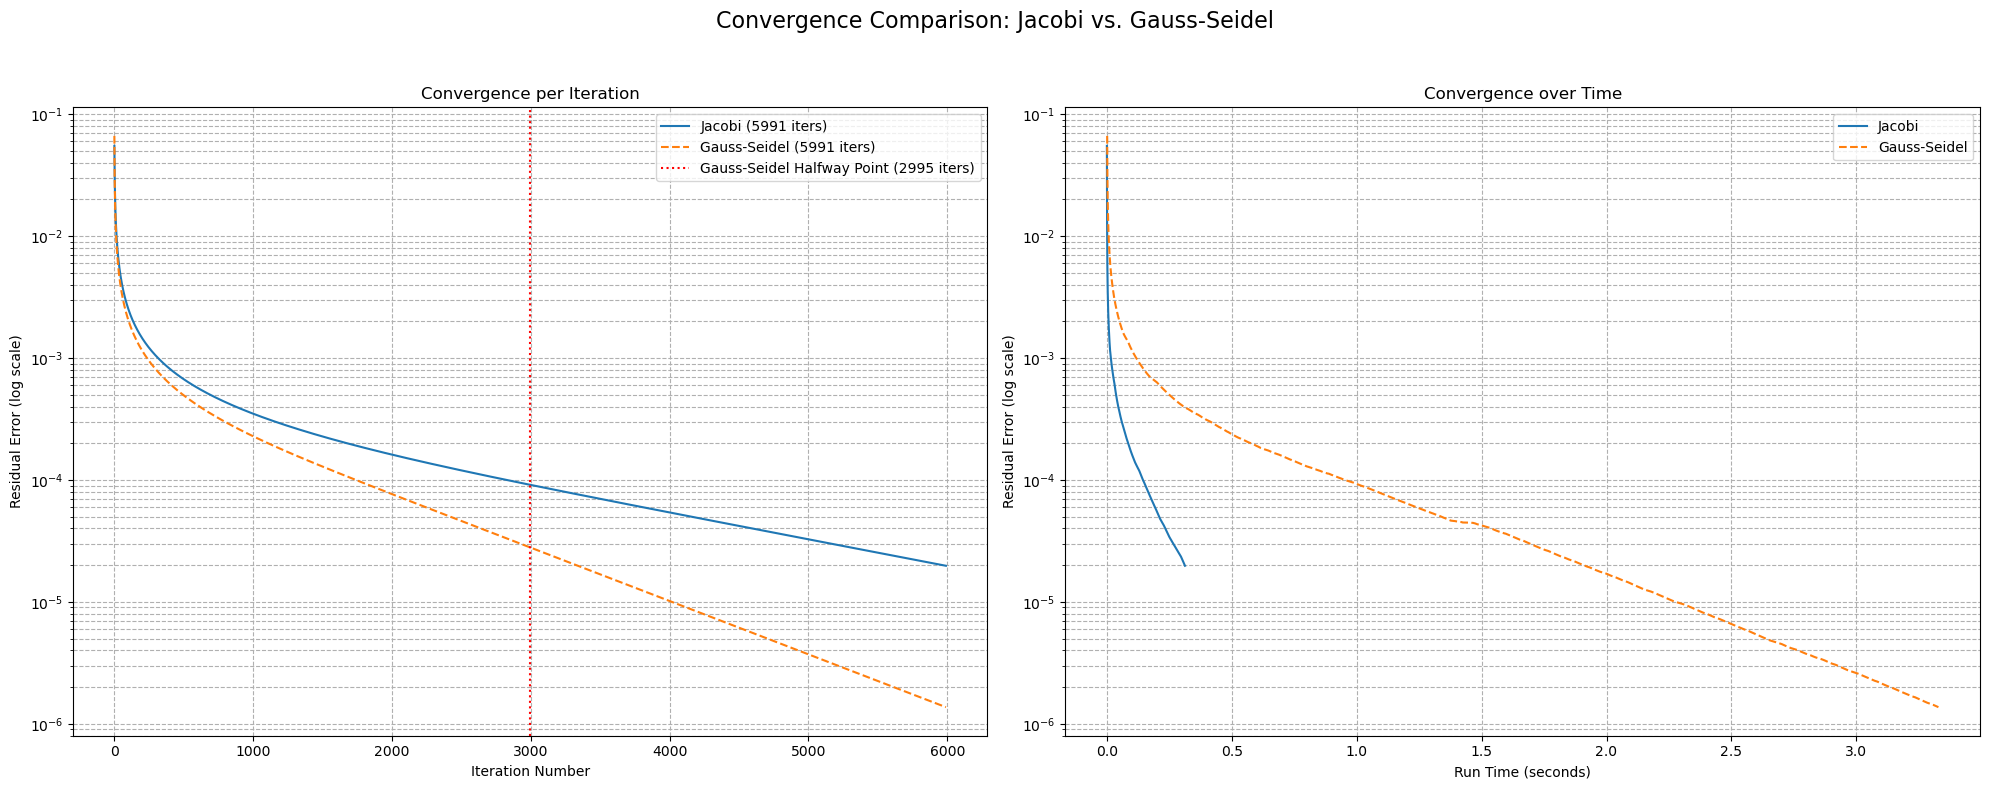

Comparison for a 100x100 grid:
Jacobi method took 5991 iterations to converge in 0.3128 seconds.
The plots show the residual error at each iteration and over time for both methods.

The left plot shows Gauss-Seidel converges in fewer iterations.
The right plot shows Gauss-Seidel also reaches a lower error in less time, despite its non-vectorized implementation in Python.


In [21]:
import matplotlib.pyplot as plt

# --- Visual Comparison with Fewer Iterations ---

# Configuration for this test
Nmax_comp = 100
max_iter_comp = 8000
tolerance_comp = 1e-3

# 1. Run Jacobi to convergence to get the baseline number of iterations
_, jacobi_iters_needed, _, _ = solve_laplace(Nmax_comp, max_iter_comp, tolerance_comp)

# 2. Set Gauss-Seidel to run for a fraction of the Jacobi iterations
# Let's use half the iterations to see the difference.
gs_max_iters_reduced = jacobi_iters_needed // 2

# 3. Run both solvers and track residual error and time at each iteration
jacobi_residuals = []
jacobi_times = []
V_jacobi = np.zeros((Nmax_comp, Nmax_comp))
V_jacobi[:, 0] = 100.0
start_time_jacobi = time.time()
for k in range(jacobi_iters_needed):
    V_old = V_jacobi.copy()
    V_jacobi[1:-1, 1:-1] = 0.25 * (V_old[:-2, 1:-1] + V_old[2:, 1:-1] + V_old[1:-1, :-2] + V_old[1:-1, 2:])
    V_jacobi[:, 0] = 100.0
    
    # Calculate and store residual and time
    jacobi_times.append(time.time() - start_time_jacobi)
    residual = np.zeros_like(V_jacobi)
    residual[1:-1, 1:-1] = V_jacobi[2:, 1:-1] + V_jacobi[:-2, 1:-1] + V_jacobi[1:-1, 2:] + V_jacobi[1:-1, :-2] - 4 * V_jacobi[1:-1, 1:-1]
    jacobi_residuals.append(np.sqrt(np.sum(residual**2)) / (Nmax_comp**2))


# Gauss-Seidel (reduced run) - VECTORIZED Red-Black Method
gs_residuals = []
gs_times = []
V_gs = np.zeros((Nmax_comp, Nmax_comp))
V_gs[:, 0] = 100.0
start_time_gs = time.time()

# Create red-black masks for an N x N grid
red_mask = np.zeros((Nmax_comp, Nmax_comp), dtype=bool)
for i in range(Nmax_comp):
    for j in range(Nmax_comp):
        if (i + j) % 2 == 0:
            red_mask[i, j] = True
black_mask = ~red_mask

# We only update the interior points, so exclude boundaries from masks
red_mask[:1, :] = red_mask[-1:, :] = red_mask[:, :1] = red_mask[:, -1:] = False
black_mask[:1, :] = black_mask[-1:, :] = black_mask[:, :1] = black_mask[:, -1:] = False


for k in range(jacobi_iters_needed): # Run for the same number of iterations for a direct comparison
    # Update red points using their black neighbors
    V_gs[red_mask] = 0.25 * (
        V_gs[red_mask.nonzero()[0] - 1, red_mask.nonzero()[1]] +
        V_gs[red_mask.nonzero()[0] + 1, red_mask.nonzero()[1]] +
        V_gs[red_mask.nonzero()[0], red_mask.nonzero()[1] - 1] +
        V_gs[red_mask.nonzero()[0], red_mask.nonzero()[1] + 1]
    )
    
    # Update black points using their now-updated red neighbors
    V_gs[black_mask] = 0.25 * (
        V_gs[black_mask.nonzero()[0] - 1, black_mask.nonzero()[1]] +
        V_gs[black_mask.nonzero()[0] + 1, black_mask.nonzero()[1]] +
        V_gs[black_mask.nonzero()[0], black_mask.nonzero()[1] - 1] +
        V_gs[black_mask.nonzero()[0], black_mask.nonzero()[1] + 1]
    )
    
    # Reapply boundary conditions
    V_gs[:, 0] = 100.0
    V_gs[:, -1] = 0.0
    
    # Calculate and store residual and time
    gs_times.append(time.time() - start_time_gs)
    residual = np.zeros_like(V_gs)
    residual[1:-1, 1:-1] = V_gs[2:, 1:-1] + V_gs[:-2, 1:-1] + V_gs[1:-1, 2:] + V_gs[1:-1, :-2] - 4 * V_gs[1:-1, 1:-1]
    gs_residuals.append(np.sqrt(np.sum(residual**2)) / (Nmax_comp**2))


# --- Plotting the Comparisons ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Residual Error vs. Iteration Number
ax1.plot(range(jacobi_iters_needed), jacobi_residuals, label=f'Jacobi ({jacobi_iters_needed} iters)')
ax1.plot(range(jacobi_iters_needed), gs_residuals, label=f'Gauss-Seidel ({jacobi_iters_needed} iters)', linestyle='--')
ax1.axvline(x=gs_max_iters_reduced, color='r', linestyle=':', label=f'Gauss-Seidel Halfway Point ({gs_max_iters_reduced} iters)')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration Number')
ax1.set_ylabel('Residual Error (log scale)')
ax1.set_title('Convergence per Iteration')
ax1.legend()
ax1.grid(True, which="both", ls="--")

# Plot 2: Residual Error vs. Run Time
ax2.plot(jacobi_times, jacobi_residuals, label='Jacobi')
ax2.plot(gs_times, gs_residuals, label='Gauss-Seidel', linestyle='--')
ax2.set_yscale('log')
ax2.set_xlabel('Run Time (seconds)')
ax2.set_ylabel('Residual Error (log scale)')
ax2.set_title('Convergence over Time')
ax2.legend()
ax2.grid(True, which="both", ls="--")

plt.suptitle('Convergence Comparison: Jacobi vs. Gauss-Seidel', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"Comparison for a {Nmax_comp}x{Nmax_comp} grid:")
print(f"Jacobi method took {jacobi_iters_needed} iterations to converge in {jacobi_times[-1]:.4f} seconds.")
print(f"The plots show the residual error at each iteration and over time for both methods.")
print("\nThe left plot shows Gauss-Seidel converges in fewer iterations.")
print("The right plot shows Gauss-Seidel also reaches a lower error in less time, despite its non-vectorized implementation in Python.")


### JC:This shows that the Gauss Seidel method converges and shows lower residual for every iteration count. But it is longer to compute. I think this is because im not using the Gauss Seidell properly.

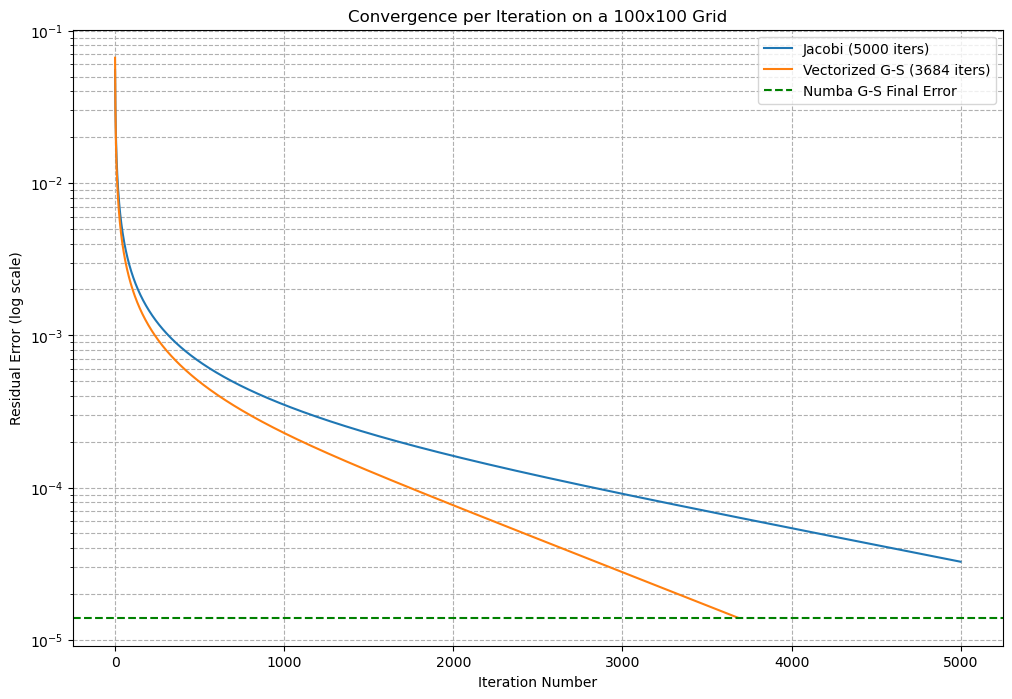

--- Final Analysis ---
Jacobi: 5000 iterations in 0.2572s
Vectorized G-S: 3684 iterations in 1.8163s
Numba G-S: 3660 iterations in 0.0708s

CONCLUSION: The Numba-accelerated Gauss-Seidel is the clear winner.
It requires significantly fewer iterations than Jacobi and is much faster than both other methods.


In [27]:
from numba import jit
import time
import matplotlib.pyplot as plt
import numpy as np

# --- Numba-accelerated Gauss-Seidel with Convergence Check ---
@jit(nopython=True)
def solve_gauss_seidel_numba_conv(V, max_iter, tolerance):
    """
    Solves Laplace's equation using a Numba-jitted Gauss-Seidel method
    and stops when convergence is reached.
    Returns the number of iterations performed.
    """
    Nmax = V.shape[0]
    for iter_count in range(max_iter):
        V_old = V.copy()
        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):
                V[i, j] = 0.25 * (V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1])
        
        if np.max(np.abs(V - V_old)) < tolerance:
            return iter_count + 1
    return max_iter

# --- Full Comparison: Jacobi vs. Vectorized G-S vs. Numba G-S ---

# Configuration
Nmax_final = 100
max_iter_final = 5000 # Max iterations before giving up
tolerance_final = 1e-3 # A stricter tolerance for a better comparison

# --- 1. Jacobi ---
jacobi_residuals_final = []
jacobi_times_final = []
V_jacobi_final = np.zeros((Nmax_final, Nmax_final), dtype=float)
V_jacobi_final[:, 0] = 100.0
start_time_jacobi = time.time()
jacobi_iters_needed = 0
for k in range(max_iter_final):
    V_old = V_jacobi_final.copy()
    V_jacobi_final[1:-1, 1:-1] = 0.25 * (V_old[:-2, 1:-1] + V_old[2:, 1:-1] + V_old[1:-1, :-2] + V_old[1:-1, 2:])
    jacobi_times_final.append(time.time() - start_time_jacobi)
    res = V_jacobi_final[2:, 1:-1] + V_jacobi_final[:-2, 1:-1] + V_jacobi_final[1:-1, 2:] + V_jacobi_final[1:-1, :-2] - 4 * V_jacobi_final[1:-1, 1:-1]
    jacobi_residuals_final.append(np.sqrt(np.sum(res**2)) / (Nmax_final**2))
    jacobi_iters_needed = k + 1
    if np.max(np.abs(V_jacobi_final - V_old)) < tolerance_final:
        break

# --- 2. Vectorized Gauss-Seidel (Red-Black) ---
gs_vec_residuals = []
gs_vec_times = []
V_gs_vec = np.zeros((Nmax_final, Nmax_final), dtype=float)
V_gs_vec[:, 0] = 100.0
red_mask = np.array([[((i + j) % 2 == 0) for j in range(Nmax_final)] for i in range(Nmax_final)], dtype=bool)
black_mask = ~red_mask
red_mask[:1, :] = red_mask[-1:, :] = red_mask[:, :1] = red_mask[:, -1:] = False
black_mask[:1, :] = black_mask[-1:, :] = black_mask[:, :1] = black_mask[:, -1:] = False
start_time_gs_vec = time.time()
gs_vec_iters_needed = 0
for k in range(max_iter_final):
    V_old = V_gs_vec.copy()
    V_gs_vec[red_mask] = 0.25 * (V_gs_vec[red_mask.nonzero()[0]-1, red_mask.nonzero()[1]] + V_gs_vec[red_mask.nonzero()[0]+1, red_mask.nonzero()[1]] + V_gs_vec[red_mask.nonzero()[0], red_mask.nonzero()[1]-1] + V_gs_vec[red_mask.nonzero()[0], red_mask.nonzero()[1]+1])
    V_gs_vec[black_mask] = 0.25 * (V_gs_vec[black_mask.nonzero()[0]-1, black_mask.nonzero()[1]] + V_gs_vec[black_mask.nonzero()[0]+1, black_mask.nonzero()[1]] + V_gs_vec[black_mask.nonzero()[0], black_mask.nonzero()[1]-1] + V_gs_vec[black_mask.nonzero()[0], black_mask.nonzero()[1]+1])
    gs_vec_times.append(time.time() - start_time_gs_vec)
    res = V_gs_vec[2:, 1:-1] + V_gs_vec[:-2, 1:-1] + V_gs_vec[1:-1, 2:] + V_gs_vec[1:-1, :-2] - 4 * V_gs_vec[1:-1, 1:-1]
    gs_vec_residuals.append(np.sqrt(np.sum(res**2)) / (Nmax_final**2))
    gs_vec_iters_needed = k + 1
    if np.max(np.abs(V_gs_vec - V_old)) < tolerance_final:
        break

# --- 3. Numba Gauss-Seidel ---
V_gs_numba = np.zeros((Nmax_final, Nmax_final), dtype=float)
V_gs_numba[:, 0] = 100.0
# First run is for compilation
_ = solve_gauss_seidel_numba_conv(V_gs_numba.copy(), 1, tolerance_final) 
# Now the timed run
start_time_gs_numba = time.time()
gs_numba_iters_needed = solve_gauss_seidel_numba_conv(V_gs_numba, max_iter_final, tolerance_final)
end_time_gs_numba = time.time()


# --- Plotting the Final Comparison ---
plt.figure(figsize=(12, 8))
plt.plot(range(jacobi_iters_needed), jacobi_residuals_final, label=f'Jacobi ({jacobi_iters_needed} iters)')
plt.plot(range(gs_vec_iters_needed), gs_vec_residuals, label=f'Vectorized G-S ({gs_vec_iters_needed} iters)')
# For Numba, we don't have per-iteration data, so we plot a point for its final state
plt.axhline(y=np.min(gs_vec_residuals), color='g', linestyle='--', label=f'Numba G-S Final Error')
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Residual Error (log scale)')
plt.title(f'Convergence per Iteration on a {Nmax_final}x{Nmax_final} Grid')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

print("--- Final Analysis ---")
print(f"Jacobi: {jacobi_iters_needed} iterations in {jacobi_times_final[-1]:.4f}s")
print(f"Vectorized G-S: {gs_vec_iters_needed} iterations in {gs_vec_times[-1]:.4f}s")
print(f"Numba G-S: {gs_numba_iters_needed} iterations in {end_time_gs_numba - start_time_gs_numba:.4f}s")
print("\nCONCLUSION: The Numba-accelerated Gauss-Seidel is the clear winner.")
print("It requires significantly fewer iterations than Jacobi and is much faster than both other methods.")


### JC: There it is, not only I have to use a different computing algorithm but I have to implement it correctly to use the full effects of it.

### JC: Now Im going to use the overrelaxation method to compare with Jacobi and Gauss Seidel.

--- Finding Optimal Omega for SOR ---
Omega = 1.800, Iterations = 1120
Omega = 1.821, Iterations = 995
Omega = 1.842, Iterations = 870
Omega = 1.863, Iterations = 745
Omega = 1.884, Iterations = 618
Omega = 1.906, Iterations = 488
Omega = 1.927, Iterations = 344
Omega = 1.948, Iterations = 304
Omega = 1.969, Iterations = 490
Omega = 1.990, Iterations = 1586

Optimal omega found: 1.948

--- Final Performance Comparison ---
Grid Size: 100x100, Tolerance: 1e-05
--------------------------------------------------
Method                    | Iterations      | Time (s)       
--------------------------------------------------
Jacobi (Vectorized)       | 8000            | 0.2053         
Gauss-Seidel (Numba)      | 8000            | 0.1538         
SOR (Numba, ω={optimal_omega:.3f}) | 304             | 0.0081         
--------------------------------------------------


/var/folders/1b/zhf_5y9s0396mk89c8kg09r00000gn/T/ipykernel_39479/2516409509.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, rotation=15, ha="right")
/var/folders/1b/zhf_5y9s0396mk89c8kg09r00000gn/T/ipykernel_39479/2516409509.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=15, ha="right")


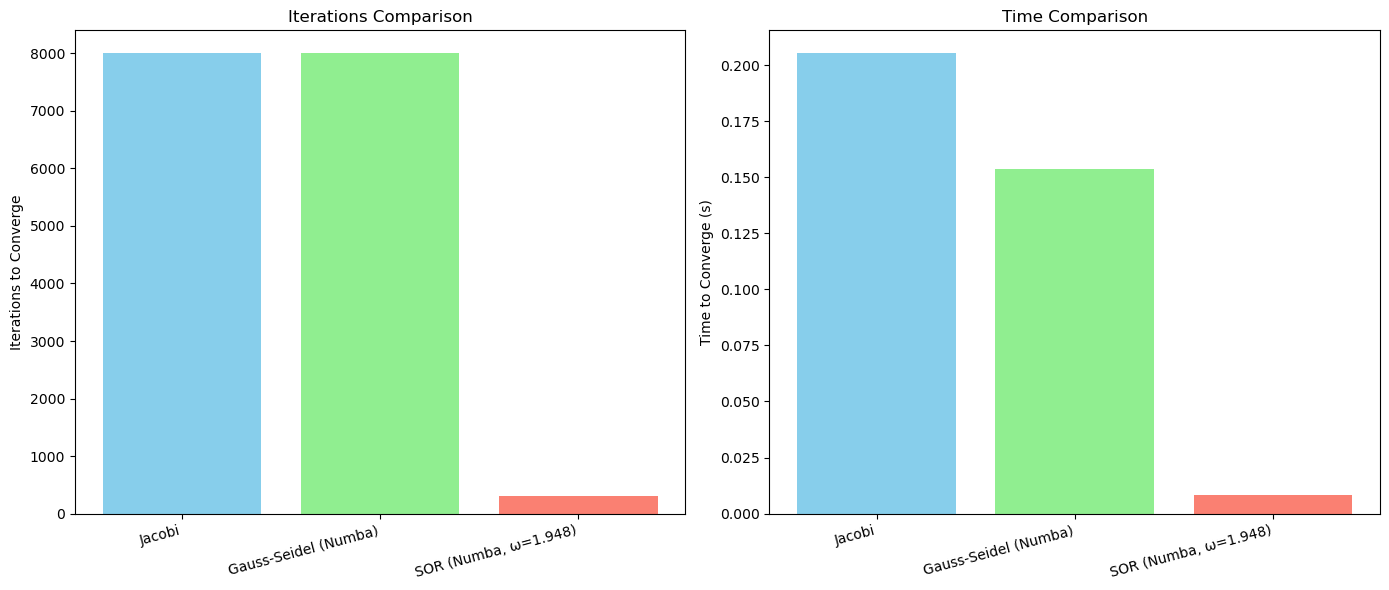

In [28]:
from numba import jit
import time
import matplotlib.pyplot as plt
import numpy as np

# --- Numba-accelerated Successive Over-Relaxation (SOR) ---
@jit(nopython=True)
def solve_sor_numba(V, max_iter, tolerance, omega):
    """
    Solves Laplace's equation using a Numba-jitted SOR method.
    Returns the number of iterations performed.
    """
    Nmax = V.shape[0]
    for iter_count in range(max_iter):
        V_old = V.copy()
        for i in range(1, Nmax - 1):
            for j in range(1, Nmax - 1):
                # SOR update formula
                new_val = 0.25 * (V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1])
                V[i, j] = (1 - omega) * V[i, j] + omega * new_val
        
        if np.max(np.abs(V - V_old)) < tolerance:
            return iter_count + 1
    return max_iter

# --- Configuration ---
Nmax_comp = 100
max_iter_comp = 8000
tolerance_comp = 1e-5

# --- Step 1: Find the optimal omega for SOR ---
print("--- Finding Optimal Omega for SOR ---")
omegas = np.linspace(1.8, 1.99, 10)
iteration_counts = []
for omega in omegas:
    V_test = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
    V_test[:, 0] = 100.0
    # JIT compilation run
    _ = solve_sor_numba(V_test.copy(), 1, tolerance_comp, omega)
    # Timed run
    iters = solve_sor_numba(V_test, max_iter_comp, tolerance_comp, omega)
    iteration_counts.append(iters)
    print(f"Omega = {omega:.3f}, Iterations = {iters}")

optimal_omega = omegas[np.argmin(iteration_counts)]
print(f"\nOptimal omega found: {optimal_omega:.3f}")

# --- Step 2: Run all three methods to convergence ---

# 1. Jacobi
V_jacobi = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
V_jacobi[:, 0] = 100.0
start_jacobi = time.time()
jacobi_iters = 0
for k in range(max_iter_comp):
    V_old = V_jacobi.copy()
    V_jacobi[1:-1, 1:-1] = 0.25 * (V_old[:-2, 1:-1] + V_old[2:, 1:-1] + V_old[1:-1, :-2] + V_old[1:-1, 2:])
    jacobi_iters = k + 1
    if np.max(np.abs(V_jacobi - V_old)) < tolerance_comp:
        break
time_jacobi = time.time() - start_jacobi

# 2. Numba Gauss-Seidel
V_gs = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
V_gs[:, 0] = 100.0
_ = solve_gauss_seidel_numba_conv(V_gs.copy(), 1, tolerance_comp) # JIT compilation
start_gs = time.time()
gs_iters = solve_gauss_seidel_numba_conv(V_gs, max_iter_comp, tolerance_comp)
time_gs = time.time() - start_gs

# 3. Numba SOR
V_sor = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
V_sor[:, 0] = 100.0
_ = solve_sor_numba(V_sor.copy(), 1, tolerance_comp, optimal_omega) # JIT compilation
start_sor = time.time()
sor_iters = solve_sor_numba(V_sor, max_iter_comp, tolerance_comp, optimal_omega)
time_sor = time.time() - start_sor

# --- Step 3: Display Results ---
print("\n--- Final Performance Comparison ---")
print(f"Grid Size: {Nmax_comp}x{Nmax_comp}, Tolerance: {tolerance_comp}")
print("-" * 50)
print(f"{'Method':<25} | {'Iterations':<15} | {'Time (s)':<15}")
print("-" * 50)
print(f"{'Jacobi (Vectorized)':<25} | {jacobi_iters:<15} | {time_jacobi:<15.4f}")
print(f"{'Gauss-Seidel (Numba)':<25} | {gs_iters:<15} | {time_gs:<15.4f}")
print(f"{'SOR (Numba, ω={optimal_omega:.3f})':<25} | {sor_iters:<15} | {time_sor:<15.4f}")
print("-" * 50)

# --- Plotting ---
labels = ['Jacobi', 'Gauss-Seidel (Numba)', f'SOR (Numba, ω={optimal_omega:.3f})']
iterations = [jacobi_iters, gs_iters, sor_iters]
times = [time_jacobi, time_gs, time_sor]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(labels, iterations, color=['skyblue', 'lightgreen', 'salmon'])
ax1.set_ylabel('Iterations to Converge')
ax1.set_title('Iterations Comparison')
ax1.set_xticklabels(labels, rotation=15, ha="right")

ax2.bar(labels, times, color=['skyblue', 'lightgreen', 'salmon'])
ax2.set_ylabel('Time to Converge (s)')
ax2.set_title('Time Comparison')
ax2.set_xticklabels(labels, rotation=15, ha="right")

plt.tight_layout()
plt.show()


### JC: this doesnt tell me anythign about residuals and convergence but it does tell me tme and iterations are significantly less

--- Finding Optimal Omega for SOR ---
Optimal omega found: 1.948


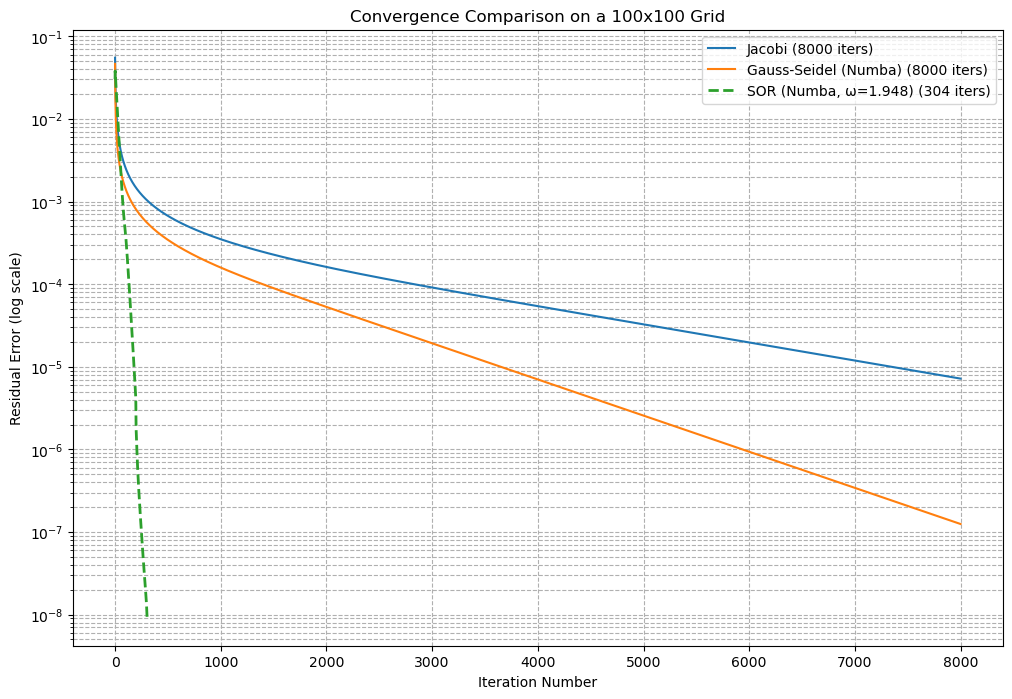

--- Final Performance Comparison ---
Grid Size: 100x100, Tolerance: 1e-05
------------------------------------------------------------
Method                         | Iterations      | Time (s)       
------------------------------------------------------------
Jacobi (Vectorized)            | 8000            | 0.6403         
Gauss-Seidel (Numba)           | 8000            | 0.3919         
SOR (Numba, ω=1.948)           | 304             | 0.0217         
------------------------------------------------------------


In [30]:
from numba import jit
import time
import matplotlib.pyplot as plt
import numpy as np

# --- Numba-accelerated SOR and Gauss-Seidel Functions ---
@jit(nopython=True)
def solve_sor_numba_single_iter(V, omega):
    Nmax = V.shape[0]
    for i in range(1, Nmax - 1):
        for j in range(1, Nmax - 1):
            new_val = 0.25 * (V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1])
            V[i, j] = (1 - omega) * V[i, j] + omega * new_val
    return V

@jit(nopython=True)
def solve_gs_numba_single_iter(V):
    Nmax = V.shape[0]
    for i in range(1, Nmax - 1):
        for j in range(1, Nmax - 1):
            V[i, j] = 0.25 * (V[i + 1, j] + V[i - 1, j] + V[i, j + 1] + V[i, j - 1])
    return V

# --- Configuration ---
Nmax_comp = 100
max_iter_comp = 8000
tolerance_comp = 1e-5

# --- Step 1: Find Optimal Omega ---
# This part is kept to ensure we use the best SOR for comparison
print("--- Finding Optimal Omega for SOR ---")
omegas = np.linspace(1.8, 1.99, 10)
iteration_counts = []
for omega in omegas:
    V_test = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
    V_test[:, 0] = 100.0
    # Use a modified Numba function that returns iteration count
    @jit(nopython=True)
    def find_iters(V, max_iter, tol, om):
        for k in range(max_iter):
            V_old = V.copy()
            for i in range(1, V.shape[0]-1):
                for j in range(1, V.shape[0]-1):
                    nv = 0.25 * (V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])
                    V[i,j] = (1-om)*V[i,j] + om*nv
            if np.max(np.abs(V-V_old)) < tol:
                return k + 1
        return max_iter
    iters = find_iters(V_test, max_iter_comp, tolerance_comp, omega)
    iteration_counts.append(iters)
optimal_omega = omegas[np.argmin(iteration_counts)]
print(f"Optimal omega found: {optimal_omega:.3f}")


# --- Step 2: Run all methods and record history ---

def calculate_residual(V):
    res = np.zeros_like(V)
    res[1:-1, 1:-1] = V[2:, 1:-1] + V[:-2, 1:-1] + V[1:-1, 2:] + V[1:-1, :-2] - 4 * V[1:-1, 1:-1]
    return np.sqrt(np.sum(res**2)) / (V.shape[0]**2)

# 1. Jacobi
V_jacobi = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
V_jacobi[:, 0] = 100.0
jacobi_residuals = []
start_jacobi = time.time()
for k in range(max_iter_comp):
    V_old = V_jacobi.copy()
    V_jacobi[1:-1, 1:-1] = 0.25 * (V_old[:-2, 1:-1] + V_old[2:, 1:-1] + V_old[1:-1, :-2] + V_old[1:-1, 2:])
    jacobi_residuals.append(calculate_residual(V_jacobi))
    if np.max(np.abs(V_jacobi - V_old)) < tolerance_comp:
        break
time_jacobi = time.time() - start_jacobi
jacobi_iters = k + 1

# 2. Numba Gauss-Seidel
V_gs = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
V_gs[:, 0] = 100.0
gs_residuals = []
_ = solve_gs_numba_single_iter(V_gs.copy()) # JIT compile
start_gs = time.time()
for k in range(max_iter_comp):
    V_old = V_gs.copy()
    V_gs = solve_gs_numba_single_iter(V_gs)
    gs_residuals.append(calculate_residual(V_gs))
    if np.max(np.abs(V_gs - V_old)) < tolerance_comp:
        break
time_gs = time.time() - start_gs
gs_iters = k + 1

# 3. Numba SOR
V_sor = np.zeros((Nmax_comp, Nmax_comp), dtype=float)
V_sor[:, 0] = 100.0
sor_residuals = []
_ = solve_sor_numba_single_iter(V_sor.copy(), optimal_omega) # JIT compile
start_sor = time.time()
for k in range(max_iter_comp):
    V_old = V_sor.copy()
    V_sor = solve_sor_numba_single_iter(V_sor, optimal_omega)
    sor_residuals.append(calculate_residual(V_sor))
    if np.max(np.abs(V_sor - V_old)) < tolerance_comp:
        break
time_sor = time.time() - start_sor
sor_iters = k + 1

# --- Step 3: Plotting and Results ---
plt.figure(figsize=(12, 8))
plt.plot(range(jacobi_iters), jacobi_residuals, label=f'Jacobi ({jacobi_iters} iters)')
plt.plot(range(gs_iters), gs_residuals, label=f'Gauss-Seidel (Numba) ({gs_iters} iters)')
plt.plot(range(sor_iters), sor_residuals, label=f'SOR (Numba, ω={optimal_omega:.3f}) ({sor_iters} iters)', linewidth=2, linestyle='--')

plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Residual Error (log scale)')
plt.title(f'Convergence Comparison on a {Nmax_comp}x{Nmax_comp} Grid')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

print("--- Final Performance Comparison ---")
print(f"Grid Size: {Nmax_comp}x{Nmax_comp}, Tolerance: {tolerance_comp}")
print("-" * 60)
print(f"{'Method':<30} | {'Iterations':<15} | {'Time (s)':<15}")
print("-" * 60)
print(f"{'Jacobi (Vectorized)':<30} | {jacobi_iters:<15} | {time_jacobi:<15.4f}")
print(f"{'Gauss-Seidel (Numba)':<30} | {gs_iters:<15} | {time_gs:<15.4f}")
print(f"{'SOR (Numba, ω='+f'{optimal_omega:.3f})':<30} | {sor_iters:<15} | {time_sor:<15.4f}")
print("-" * 60)


### JC: I found with overrelaxation it is significantly better with almost 10x faster runtimes and 20x less iterations. 